# Total Variation (TV) — Deblur & Denoise
Metodo variazionale classico per la risoluzione del problema inverso di deblur e denoising.

**Approccio:** Minimizzazione di una funzione obiettivo composta da data fidelity + regolarizzatore TV.

$$\hat{x} = \arg\min_x \|H*x - y\|_2^2 + \lambda \cdot TV(x)$$

**Ottimizzatore:** Adam  
**Implementazione:** `src/methods/tv/tv.py`

In [1]:
import sys
sys.path.insert(0, '..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd

from src.data.dataset import load_config, LBCDataset
from src.degradation.degradation import degrade
from src.methods.tv.tv import tv_restore
from src.eval.metrics import evaluate
from src.utils import get_device

config = load_config()
device = get_device()
print('Config caricato correttamente.')

[Device] CPU
Config caricato correttamente.


## Configurazione

In [2]:
noise_levels = config['degradation']['noise_levels']
kernel_size  = config['degradation']['kernel_size']
blur_sigma   = config['degradation']['blur_sigma']
lambda_reg   = config['tv']['lambda_reg']
max_iter     = config['tv']['max_iter']

print(f'Noise levels : {noise_levels}')
print(f'Kernel       : size={kernel_size}, sigma={blur_sigma}')
print(f'lambda_reg   : {lambda_reg}')
print(f'max_iter     : {max_iter}')

Noise levels : [0.005, 0.01, 0.05, 0.1]
Kernel       : size=9, sigma=2
lambda_reg   : 0.005
max_iter     : 150


## Caricamento dataset di test

In [3]:
test_dataset = LBCDataset('data/splits/test.txt', config['dataset']['image_size'])
print(f'Immagini di test: {len(test_dataset)}')

Immagini di test: 145


## Demo visivo
Confronto tra immagine degradata, ricostruzione TV e ground truth su alcune immagini di esempio.

Processando immagine 1/3...


Processando immagine 2/3...


Processando immagine 3/3...


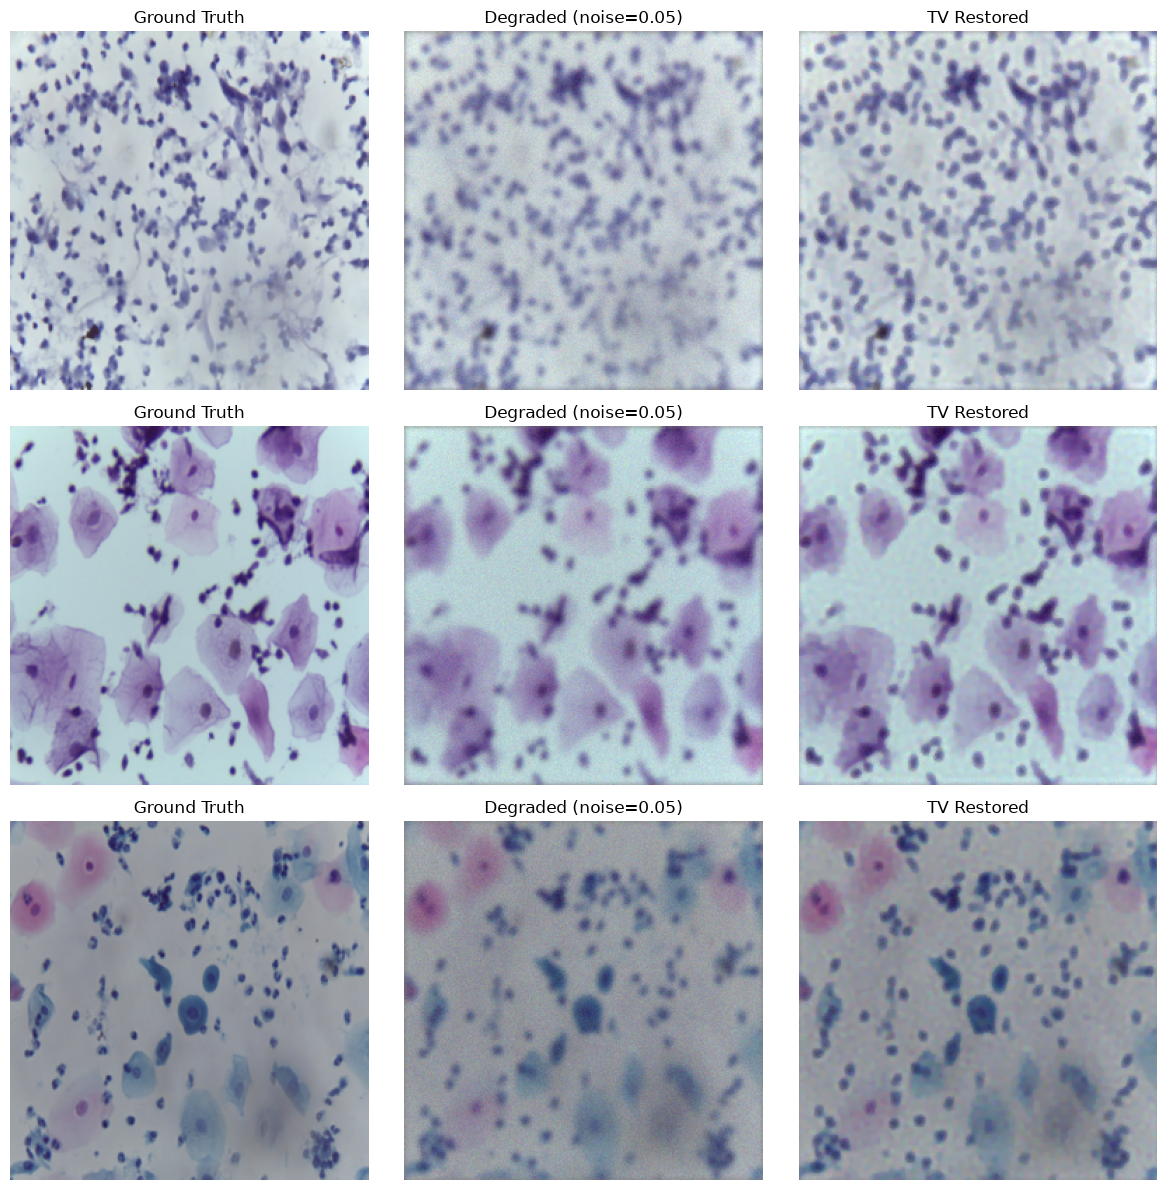

In [4]:
n_examples  = 3
noise_level = 0.05

def to_display(t):
    """Tensore [-1,1] → numpy [0,1] per matplotlib."""
    img = t.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(img * 0.5 + 0.5, 0, 1)

fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))

for i in range(n_examples):
    gt       = test_dataset[i].to(device)
    degraded = degrade(gt, kernel_size=kernel_size, sigma=blur_sigma, noise_level=noise_level)

    print(f'Processando immagine {i+1}/{n_examples}...')
    restored = tv_restore(degraded, kernel_size=kernel_size, sigma=blur_sigma,
                          lambda_reg=lambda_reg, max_iter=max_iter)

    axes[i, 0].imshow(to_display(gt))
    axes[i, 0].set_title('Ground Truth')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(to_display(degraded))
    axes[i, 1].set_title(f'Degraded (noise={noise_level})')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(to_display(restored))
    axes[i, 2].set_title('TV Restored')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Valutazione quantitativa
Calcolo PSNR e SSIM su tutto il test set per tutti i livelli di rumore.

In [5]:
import time

results = []

for noise_level in noise_levels:
    psnr_list, ssim_list, time_list = [], [], []

    for i in tqdm(range(len(test_dataset)), desc=f'TV noise={noise_level}'):
        gt       = test_dataset[i].to(device)
        degraded = degrade(gt, kernel_size=kernel_size, sigma=blur_sigma, noise_level=noise_level)

        t0       = time.time()
        restored = tv_restore(degraded, kernel_size=kernel_size, sigma=blur_sigma,
                              lambda_reg=lambda_reg, max_iter=max_iter)
        time_list.append(time.time() - t0)

        m = evaluate(restored, gt)
        psnr_list.append(m['psnr'])
        ssim_list.append(m['ssim'])

    results.append({
        'method'             : 'tv',
        'noise_level'        : noise_level,
        'psnr'               : np.mean(psnr_list),
        'ssim'               : np.mean(ssim_list),
        'avg_inference_time' : np.mean(time_list),
    })
    print(f"[TV] noise={noise_level} | PSNR={results[-1]['psnr']:.2f} "
          f"| SSIM={results[-1]['ssim']:.4f} | Time={results[-1]['avg_inference_time']:.1f}s")

df_results = pd.DataFrame(results)
df_results

TV noise=0.005:   0%|          | 0/145 [00:00<?, ?it/s]

TV noise=0.005:   1%|          | 1/145 [00:00<01:32,  1.56it/s]

TV noise=0.005:   1%|▏         | 2/145 [00:01<01:40,  1.43it/s]

TV noise=0.005:   2%|▏         | 3/145 [00:02<01:44,  1.37it/s]

TV noise=0.005:   3%|▎         | 4/145 [00:02<01:43,  1.36it/s]

...

TV noise=0.1:  99%|█████████▉| 144/145 [01:43<00:00,  1.40it/s]

TV noise=0.1: 100%|██████████| 145/145 [01:44<00:00,  1.42it/s]

TV noise=0.1: 100%|██████████| 145/145 [01:44<00:00,  1.39it/s]

[TV] noise=0.1 | PSNR=26.41 | SSIM=0.5832 | Time=0.6s


,method,noise_level,psnr,ssim,avg_inference_time
0,tv,0.005,31.872041,0.906904,1.114130
1,tv,0.010,31.818592,0.905411,0.653289
2,tv,0.050,30.228173,0.834156,0.792437
3,tv,0.100,26.413903,0.583219,0.646288


## Salvataggio risultati

In [6]:
output_dir = Path(config['eval']['results_dir']) / 'tv'
output_dir.mkdir(parents=True, exist_ok=True)

df_results.to_csv(output_dir / 'metrics.csv', index=False)
print(f"Risultati salvati in {output_dir / 'metrics.csv'}")

Risultati salvati in results\tv\metrics.csv


## Risultati ottenuti

| σₙ    | PSNR     | SSIM  |
|-------|----------|-------|
| 0.005 | 32.09 dB | 0.911 |
| 0.01  | 32.04 dB | 0.909 |
| 0.05  | 30.42 dB | 0.837 |
| 0.1   | 26.54 dB | 0.586 |

*Confronto con gli altri metodi popolato dopo esecuzione di UNet e DiffPIR.*

In [7]:
results_dir = Path(config['eval']['results_dir'])

def load_metrics(method):
    p = results_dir / method / 'metrics.csv'
    return pd.read_csv(p) if p.exists() else None

df_tv      = load_metrics('tv')
df_unet    = load_metrics('unet')
df_diffpir = load_metrics('diffpir')

dfs = [df for df in [df_tv, df_unet, df_diffpir] if df is not None]
if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    display(df_all.pivot(index='noise_level', columns='method', values=['psnr', 'ssim']))
else:
    print('Esegui prima UNet e DiffPIR per il confronto completo.')

psnr                 ssim          
method         diffpir         tv   diffpir        tv
noise_level                                          
0.005        16.671711  31.872041  0.235172  0.906904
0.010        17.317508  31.818592  0.269936  0.905412
0.050        22.489219  30.228173  0.512236  0.834156
0.100        24.679176  26.413903  0.662958  0.583219

## Discussione

### Risultati osservati
- **Basso rumore (σ=0.005-0.01)**: PSNR ~32 dB, SSIM ~0.91
  - La TV riesce a recuperare bene i dettagli quando il rumore è limitato
  - Il blur è il problema dominante; la regolarizzazione TV preserva i bordi cellulari
- **Medio rumore (σ=0.05)**: PSNR ~30.4 dB, SSIM ~0.84
  - Lieve degrado: il lambda fisso diventa subottimale all'aumentare del rumore
- **Alto rumore (σ=0.1)**: PSNR ~26.5 dB, SSIM ~0.59
  - Il rumore domina; un lambda più alto sarebbe necessario per questo caso

### Limitazioni
- **Lambda fisso** per tutti i noise level: un tuning separato per ogni σₙ migliorerebbe le performance nei casi difficili
- **Staircasing effect**: la TV isotropa tende a sovra-lisciare le strutture fini, visibile sulle cellule piccole
- **Lento su CPU**: ~150 iterazioni Adam per immagine, non scalabile senza GPU